In [4]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [5]:
def create_mfcc(df, segmented_dir, all_categories, n_mfcc=13, hop_length=512, sr=16000):
    segmented_dir = Path(segmented_dir)
    mfcc_list = []
    labels = []
    
    for index, f in tqdm(df.iterrows()):
        for file in segmented_dir.glob(f'{Path(f.fname).stem}_*.wav'):
            y, _ = librosa.load(file, sr=sr)
            n_fft = min(2048, len(y))
            mfcc = librosa.feature.mfcc(y=y, 
                                        sr=sr, 
                                        n_mfcc=n_mfcc, 
                                        n_fft=n_fft, 
                                        hop_length=hop_length)
            # mfcc_db = librosa.power_to_db(mfcc**2)
            # mfcc_list.append(mfcc_db)
            mfcc_list.append(mfcc)
            labels.append(f.label)
        
    X = np.array(mfcc_list)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    label_encoder.fit(all_categories)
    y = label_encoder.transform(labels)

    return X, y

Load train/test DataFrame

In [6]:
train_csv_path = 'meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

test_csv_path = 'meta/test_post_competition_scoring_clips.csv'
test_df = pd.read_csv(test_csv_path)

In [7]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]
test_df = test_df[test_df['label'].isin(musical_instruments)]

In [8]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('train', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

test_df = test_df[test_df['fname'].apply(lambda x: os.path.exists(os.path.join('test', x)))]
test_df = test_df.reset_index(drop=True)

Import data for model

In [9]:
X_train, y_train = create_mfcc(train_df, 'segmented_train', musical_instruments)
X_test, y_test = create_mfcc(test_df, 'segmented_test', musical_instruments)

1847it [06:07,  5.03it/s]
790it [03:07,  4.22it/s]


Plot MFCC

In [10]:
def plot_mfcc(X, i):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.show()

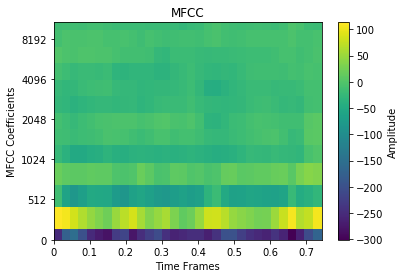

In [11]:
plot_mfcc(X_train, 5)

CNN model

In [12]:
# cnn = models.Sequential([
#     layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(len(musical_instruments), activation='softmax')
# ])

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(musical_instruments), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 13, 32, 32)        320       
_________________________________________________________________
batch_normalization (BatchNo (None, 13, 32, 32)        128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 7, 16, 32)         0         
_________________________________________________________________
dropout (Dropout)            (None, 7, 16, 32)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 7, 16, 64)         18496     
_________________________________________________________________
batch_normalization_1 (Batch (None, 7, 16, 64)         256       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 8, 64)          0

Train CNN

In [13]:

cnn.fit(X_train, y_train, epochs=30)

Epoch 1/30
235/235 [==============================] - 6s 26ms/step - loss: 1.7740 - accuracy: 0.4450
Epoch 2/30
235/235 [==============================] - 6s 26ms/step - loss: 1.1800 - accuracy: 0.6193
Epoch 3/30
235/235 [==============================] - 6s 25ms/step - loss: 0.9834 - accuracy: 0.6887
Epoch 4/30
235/235 [==============================] - 6s 25ms/step - loss: 0.8363 - accuracy: 0.7280
Epoch 5/30
235/235 [==============================] - 6s 26ms/step - loss: 0.7582 - accuracy: 0.7529
Epoch 6/30
235/235 [==============================] - 6s 26ms/step - loss: 0.6582 - accuracy: 0.7837
Epoch 7/30
235/235 [==============================] - 6s 26ms/step - loss: 0.6220 - accuracy: 0.7974
Epoch 8/30
235/235 [==============================] - 6s 27ms/step - loss: 0.5719 - accuracy: 0.8140
Epoch 9/30
235/235 [==============================] - 6s 26ms/step - loss: 0.5389 - accuracy: 0.8287
Epoch 10/30
235/235 [==============================] - 6s 26ms/step - loss: 0.5250 - accura

Evaluate CNN

In [14]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = 'cnn_mfcc_evaluation.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)


Accuracy: 0.80980271270037

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.95      0.79      0.86       215
       Bass_drum       0.94      0.36      0.52        47
           Cello       0.84      0.69      0.76        55
        Clarinet       0.85      0.91      0.88        86
         Cowbell       0.80      0.81      0.81       123
     Double_bass       0.66      0.44      0.53       154
  Electric_piano       0.85      0.83      0.84       681
           Flute       0.72      0.84      0.78       353
    Glockenspiel       0.81      0.85      0.83       328
       Harmonica       0.78      0.97      0.86        71
          Hi-hat       0.70      0.62      0.66       175
            Oboe       0.82      0.87      0.84       189
       Saxophone       0.62      1.00      0.77        35
      Tambourine       0.91      0.38      0.54        52
         Trumpet       0.83      0.86      0.84       245
Violin_or_fiddle   

Save CNN

In [15]:
cnn.save('cnn_mfcc_model.h5')